In [1]:
import pandas as pd
import numpy as np
import random

# የዘፈቀደ ዳታ ለመፍጠር የሚያስፈልጉ ዝርዝሮች
products = ["iPhone 13", "Samsung S22", "MacBook Pro", "Laptop Bag", "Shoe", "Wireless Mouse"]
prices = [45000, 38000, 120000, 2500, 3500, 1200]
addresses = ["Bole, Addis Ababa", "Megenagna, Addis Ababa", "Hawassa, Ethiopia", "Adama, Ethiopia", "Bahir Dar, Ethiopia", "Mekelle, Ethiopia"]
dates = ["2025/01/15", "2025-02-10", "2025.03.22", "2025/04/05", "2025-05-12"]

# 10,000 ዳታዎችን በ loop መፍጠር
rows = []
for i in range(10000):
    prod_idx = random.randint(0, len(products)-1)
    product = products[prod_idx]
    
    # ሆን ብሎ ዋጋው ላይ "ETB" እና "," በመጨመር ማበላሸት
    price_each = f"ETB {prices[prod_idx]:,}"
    
    # ሆን ብሎ የጎደለ (NaN) እና ከዜሮ በታች የሆነ ብዛት መጨመር
    rand_qty = random.choice([1, 2, 3, np.nan, -1, -3])
    
    # ሆን ብሎ የተዘበራረቀ ቀን እና የጎደለ ቀን መጨመር
    order_date = random.choice([random.choice(dates), np.nan])
    
    # ሆን ብሎ የጎደለ አድራሻ መጨመር
    address = random.choice([random.choice(addresses), np.nan])
    
    rows.append({
        "Order_ID": 10000 + i,
        "Product": product,
        "Price_Each": price_each,
        "Quantity_Ordered": rand_qty,
        "Order_Date": order_date,
        "Purchase_Address": address
    })

# ወደ DataFrame መቀየር እና ሴቭ ማድረግ
df_large = pd.DataFrame(rows)
# df_large.to_csv("large_messy_ethiopian_sales.csv", index=False)
# print("10,000 መስመር ያለው 'large_messy_ethiopian_sales.csv' በስኬት ተፈጥሯል!")

df=pd.read_csv("large_messy_ethiopian_sales.csv",encoding="utf-8")
# print(df.head())

df["Quantity_Ordered"]=np.abs(df["Quantity_Ordered"])
# print(df["Quantity_Ordered"].head())

df["Quantity_Ordered"]=df["Quantity_Ordered"].fillna(1)
# print(df["Quantity_Ordered"].head())

df["Price_Each"]=df["Price_Each"].str.replace("ETB" , "").str.replace("," , "")
# df["Price_Each"].head().astype(float)

df["Quantity_Ordered"] = pd.to_numeric(df["Quantity_Ordered"], errors="coerce")

df["Price_Each"] = pd.to_numeric(df["Price_Each"], errors="coerce")

df["Total_Sales"]=(df["Quantity_Ordered"]*df["Price_Each"])

print(df["Total_Sales"].head())

# ውጤቱን ለማየት በ print() መክተት አለብን ወይም ወደ አዲስ ተለዋዋጭ መገልበጥ አለብን
print("\nከፍተኛ የሽያጭ ገቢ (Revenue) ያስገነኙ ምርቶች ዝርዝር፦")
print(df.groupby("Product")["Total_Sales"].sum().sort_values(ascending=False))


df["Order_Date"] = pd.to_datetime(
    df["Order_Date"],
    format="mixed"
)
df["Order_Date"] = df["Order_Date"].dt.strftime("%Y-%m-%d")
df["Order_Date"] = df["Order_Date"].fillna("Unknown-Date")

df["Purchase_Address"]=df["Purchase_Address"].fillna("Unkown-Adress")



# print(df.head())


# df.to_csv(
#     "sales_data.csv",
#     index=False,
#     encoding="utf-8"
# )
# print("CSV file created successfully")

0      7500.0
1      2500.0
2    360000.0
3      7500.0
4     45000.0
Name: Total_Sales, dtype: float64

ከፍተኛ የሽያጭ ገቢ (Revenue) ያስገነኙ ምርቶች ዝርዝር፦
Product
MacBook Pro       351240000.0
iPhone 13         136575000.0
Samsung S22       117914000.0
Shoe               10829000.0
Laptop Bag          7710000.0
Wireless Mouse      3609600.0
Name: Total_Sales, dtype: float64


📸 ለሊንክዲን የሚሆነው ምስል 'linkedin_sales_chart.png' በሚል ስም ተቀምጧል!


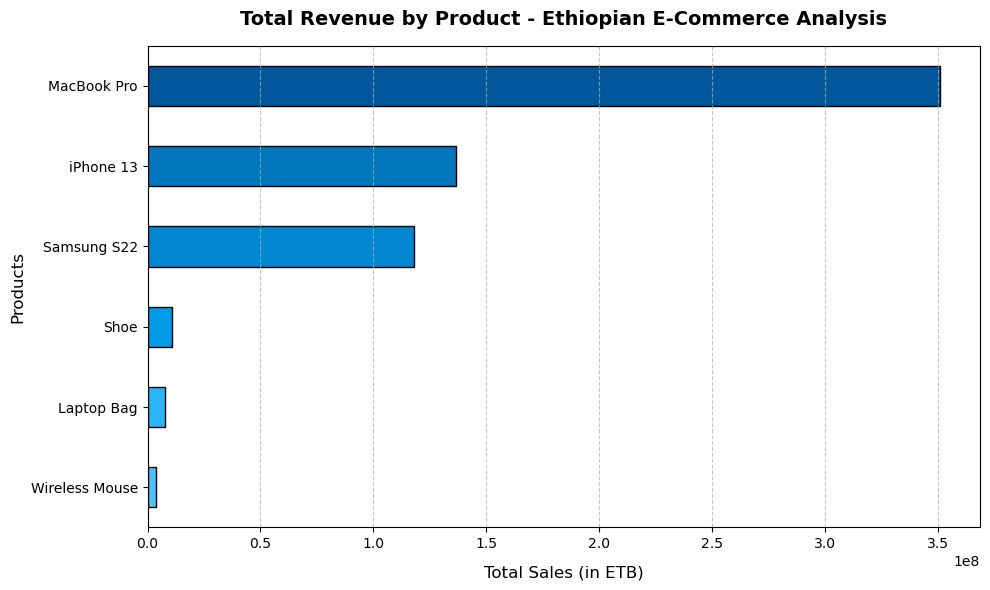

In [2]:
import matplotlib.pyplot as plt


# 1. ዳታውን በምርት ከፋፍሎ የሽያጭ ድምር ማውጣት
product_sales = df.groupby("Product")["Total_Sales"].sum().sort_values(ascending=True)

# 2. የምስሉን መጠን ማስተካከል
plt.figure(figsize=(10, 6))

# 3. አግድም የባር ግራፍ መስራት (Horizontal Bar Chart)
colors = ['#4fc3f7', '#29b6f6', '#039be5', '#0288d1', '#0277bd', '#01579b'] # ፕሮፌሽናል ሰማያዊ ቀለማት
product_sales.plot(kind='barh', color=colors, edgecolor='black')

# 4. የግራፉን ውበት ማስተካከል (Labels & Title)
plt.title("Total Revenue by Product - Ethiopian E-Commerce Analysis", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Total Sales (in ETB)", fontsize=12, labelpad=10)
plt.ylabel("Products", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# 5. ቁጥሮቹ ከምስሉ እንዳይወጡ ማድረግ
plt.tight_layout()

# 6. ምስሉን ለሊንክዲን ዝግጁ አድርጎ ሴቭ ማድረግ 📸
plt.savefig("Ethipia_Product_sales_chart.png", dpi=300)
print("📸 ለሊንክዲን የሚሆነው ምስል 'linkedin_sales_chart.png' በሚል ስም ተቀምጧል!")